# Convolutional Neural Network
### MNIST classifier



---

MNIST is a widely used dataset of handwritten digits. It contains 70,000 grayscale images of digits from 0 to 9, each of size 28×28 pixels. MNIST is commonly used for training and testing image classification algorithms and serves as a beginner-friendly benchmark in machine learning and deep learning research.

---

### Libraries


In [1]:
import os
import sys

# Path
sys.path.append(os.path.abspath(".."))

# Core
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

from numpy import array

import subprocess

from pathlib import Path
import shutil

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras import Sequential
from tensorflow.keras.layers import *
from tensorflow.keras.models import *
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import l1, l2

# Model optimization
import tensorflow_model_optimization as tfmot
from tensorflow_model_optimization.python.core.sparsity.keras import (
    prune,
    pruning_callbacks,
    pruning_schedule
)
from tensorflow_model_optimization.sparsity.keras import strip_pruning, prune_low_magnitude


# QKeras (Quantization)
from qkeras import *

# Metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils import shuffle

# Preprocessing
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder

# Dataset split
from sklearn.model_selection import train_test_split

# HLS4ML
import hls4ml

# Reproducibility
tf.random.set_seed(42)

# Clear sessions
K.clear_session()
tf.keras.backend.clear_session()

# Datasets
from tensorflow.keras.datasets import mnist, fashion_mnist, cifar10, cifar100



import sys, os
import sys
sys.path.append(os.path.abspath('../../'))
from common.notebook_utils.distillationClassKeras import Distiller
from common.notebook_utils.utils import report_classifier



2026-04-01 16:37:25.519409: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-01 16:37:25.563675: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-01 16:37:26.327242: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


/tools/anaconda3/envs/neuralEnv/lib/python3.10/site-packages/hls4ml/converters/__init__.py:27: UserWarning: WARNING: Pytorch converter is not enabled!
  warnings.warn("WARNING: Pytorch converter is not enabled!", stacklevel=1)


### Enable GPU 

In [2]:
#  GPU 
os.environ['TF_XLA_FLAGS'] = '--tf_xla_enable_xla_devices'

import tensorflow as tf
print("GPUs: ", len(tf.config.experimental.list_physical_devices('GPU')))

import tensorflow as tf
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)

    except RuntimeError as e:
        print(e)

2026-04-01 16:37:27.645658: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 16:37:27.692639: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 16:37:27.692853: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

GPUs:  1


### Dataset Loading

The MNIST dataset will be used to train the machine learning classification model. MNIST consists of 10 digits, from 0 to 9.


In [3]:
#  Loading the Dataset, Split into Training and Testing (Data and Labels)
(x_train, y_train),(x_test, y_test) = mnist.load_data()


### Preprocessing

When working with images, it's common to apply basic preprocessing, which involves normalizing the pixel values to the range [0, 1], since the original pixel values are in the range [0, 255]. This is achieved by simply dividing the original pixel values by 255.

In this case, we will apply normalization to the variables that contain the images, x_train and x_test, since y_train and y_test contain only the corresponding class labels.



In [4]:
x_train_norm, x_test_norm = x_train / 255.0, x_test / 255.0

In [5]:
x_train_norm.shape

(60000, 28, 28)

----

### Load Model

In [6]:

from qkeras.utils import _add_supported_quantized_objects

co = {}
_add_supported_quantized_objects(co)

model = tf.keras.models.load_model('../01.training/models/distilled-mnist.h5', custom_objects=co)


2026-04-01 16:37:28.302027: I tensorflow/compiler/xla/service/service.cc:169] XLA service 0x424a0d40 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-04-01 16:37:28.302067: I tensorflow/compiler/xla/service/service.cc:177]   StreamExecutor device (0): Host, Default Version
2026-04-01 16:37:28.302344: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-04-01 16:37:28.302604: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
20

---

## Integration with a hardware synthesis tool for ML

In [ ]:
# PATH Vitis HLS installation
os.environ['PATH'] = '/tools/Xilinx/Vitis_HLS/2024.1/bin:' + os.environ['PATH']
os.environ['PATH']

'/tools/Xilinx/Xilinx2024/Vitis_HLS/2024.1/bin:/tools/anaconda3/envs/neuralEnv/bin:/tools/anaconda3/condabin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/usr/games:/usr/local/games:/snap/bin'

### hls4ml

**hls4ml** is a Python package developed for converting machine learning (ML) models into HLS (High-Level Synthesis) projects, enabling deployment of ML-based inference on hardware like FPGAs. More details can be found at [hls4ml documentation](https://fastmachinelearning.org/hls4ml/).

The user can control several options related to the model, including:

- **Precision:** Define the precision of the calculations in your model (e.g., fixed-point or floating-point representation).

- **Dataflow/Resource Reuse:** Control the level of parallelism or streaming in model implementations, with varying degrees of pipelining.

An HLS configuration should be created using the function `hls4ml.utils.config_from_keras_model(kerasModel, granularity)`, where kerasModel is the pre-trained model you want to implement on an FPGA, and granularity determines the configuration level. The two possible values for granularity are:

- 'model': The same configuration applies to the entire model (e.g., all layers use 16-bit fixed-point precision).

- 'name': Layer-specific configurations can be applied (e.g., the input layer can be defined in 8-bit fixed-point precision, while the second layer is set to 16-bit fixed-point precision).

In [ ]:
# Generate an hls4ml configuration dictionary from the Keras model.
# - granularity='name'         : allows per-layer configuration by layer name
# - default_precision          : sets the default fixed-point format for all layers
#     fixed<16,12>: 16-bit total width, 12 integer bits, 4 fractional bits
# - default_reuse_factor=8     : hardware resources reused 8 times across computations
hls_config = hls4ml.utils.config_from_keras_model(
    model,
    granularity='name',
    default_precision='fixed<16,12>',
    default_reuse_factor=8
)

# --- Global Model-Level Settings ---

# Strategy       : Latency: optimizes for minimum latency
# IOType         : io_stream: data flows as a stream between layers
# RoundingMode   : AP_RND_CONV (Convergent rounding): reduces statistical bias
# SaturationMode : AP_SAT (Saturate): clamps values to min/max, prevents overflow artifacts
hls_config['Model']['Strategy']       = 'Latency'
hls_config['Model']['IOType']         = 'io_stream'
hls_config['Model']['RoundingMode']   = 'AP_RND_CONV'
hls_config['Model']['SaturationMode'] = 'AP_SAT'

# --- Layer-Specific Settings ---

# Use 'argmax' softmax implementation — avoids full exp() computation
hls_config['LayerName']['softmax']['implementation'] = 'argmax'

Interpreting Sequential
Topology:
Layer name: conv1_input, layer type: InputLayer, input shapes: [[None, 28, 28, 1]], output shape: [None, 28, 28, 1]
Layer name: conv1, layer type: QConv2D, input shapes: [[None, 28, 28, 1]], output shape: [None, 28, 28, 2]
Layer name: act1, layer type: Activation, input shapes: [[None, 28, 28, 2]], output shape: [None, 28, 28, 2]
Layer name: pool1, layer type: MaxPooling2D, input shapes: [[None, 28, 28, 2]], output shape: [None, 14, 14, 2]
Layer name: conv2, layer type: QConv2D, input shapes: [[None, 14, 14, 2]], output shape: [None, 14, 14, 4]
Layer name: act2, layer type: Activation, input shapes: [[None, 14, 14, 4]], output shape: [None, 14, 14, 4]
Layer name: pool2, layer type: MaxPooling2D, input shapes: [[None, 14, 14, 4]], output shape: [None, 7, 7, 4]
Layer name: flatten, layer type: Reshape, input shapes: [[None, 7, 7, 4]], output shape: [None, 196]
Layer name: fc1, layer type: QDense, input shapes: [[None, 196]], output shape: [None, 8]
Layer

In [ ]:
# Directory path where the HLS (High-Level Synthesis) project will be generated.
# hsl4ml translates the neural network into synthesizable RTL code for FPGA deployment.
PATH_HLS_PROJECT = '../02.hls4ml/output/'


# Create configuration for Vitis HLS as backend.
cfg = hls4ml.converters.create_config(backend='Vitis')
cfg['IOType'] = 'io_stream'   
# HLSConfig correspond to the configuration created in hls_config 
cfg['HLSConfig'] = hls_config
# Model to be converted
cfg['KerasModel'] = model
# Folder where the HLS project will be created
cfg['OutputDir'] = PATH_HLS_PROJECT
# FPGA part 
cfg['Part'] = 'xczu3eg-sfvc784-2-e'  
  


Interpreting Sequential
Topology:
Layer name: conv1_input, layer type: InputLayer, input shapes: [[None, 28, 28, 1]], output shape: [None, 28, 28, 1]
Layer name: conv1, layer type: QConv2D, input shapes: [[None, 28, 28, 1]], output shape: [None, 28, 28, 2]
Layer name: act1, layer type: Activation, input shapes: [[None, 28, 28, 2]], output shape: [None, 28, 28, 2]
Layer name: pool1, layer type: MaxPooling2D, input shapes: [[None, 28, 28, 2]], output shape: [None, 14, 14, 2]
Layer name: conv2, layer type: QConv2D, input shapes: [[None, 14, 14, 2]], output shape: [None, 14, 14, 4]
Layer name: act2, layer type: Activation, input shapes: [[None, 14, 14, 4]], output shape: [None, 14, 14, 4]
Layer name: pool2, layer type: MaxPooling2D, input shapes: [[None, 14, 14, 4]], output shape: [None, 7, 7, 4]
Layer name: flatten, layer type: Reshape, input shapes: [[None, 7, 7, 4]], output shape: [None, 196]
Layer name: fc1, layer type: QDense, input shapes: [[None, 196]], output shape: [None, 8]
Layer

bash: /tools/anaconda3/envs/neuralEnv/lib/libtinfo.so.6: no version information available (required by bash)


Done


In [ ]:
# Convert the Keras model to an HLS model using the configuration
hls_model = hls4ml.converters.keras_to_hls(cfg)

# Compile the HLS model for simulation/verification
hls_model.compile()

### Keras vs HLS model evaluation

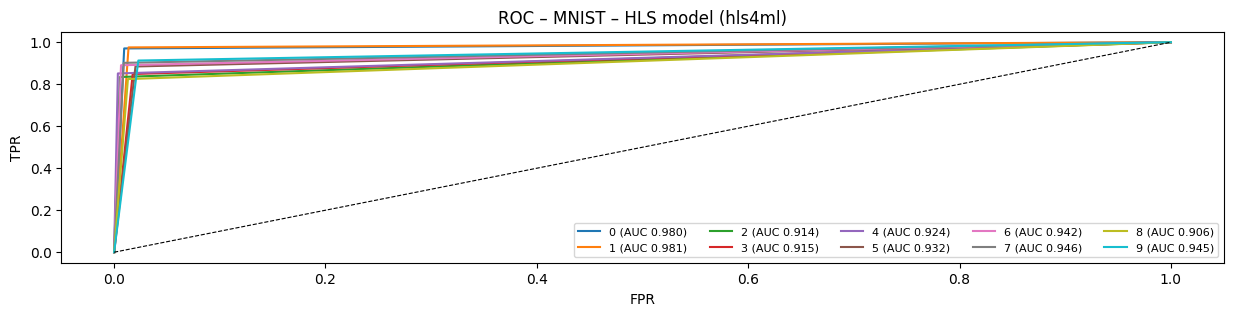

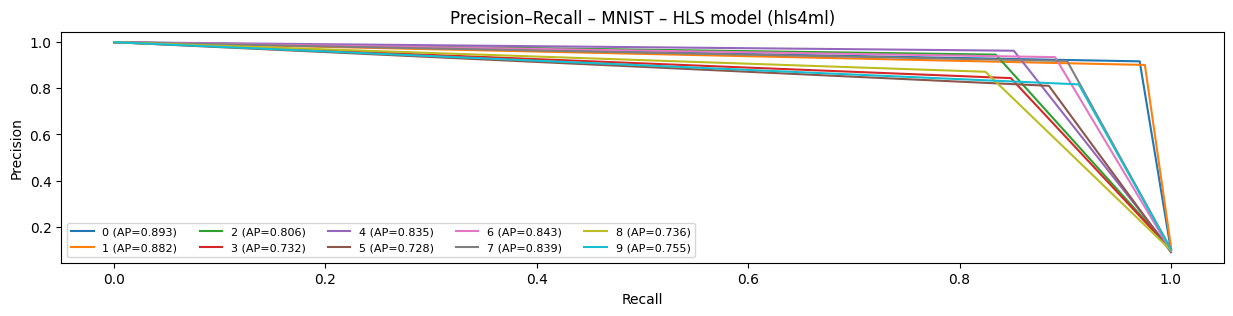

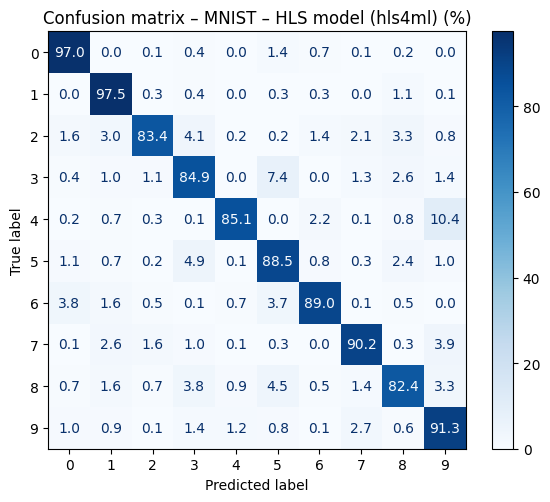

In [ ]:
figs, aucs, metrics = report_classifier(
    history=None,
    y_true=y_test,
    y_proba=hls_model.predict(x_test_norm),
    class_names=[str(i) for i in range(10)],
    model_name="MNIST – HLS model (hls4ml)",
    show=True
)

display(figs["cm"])

In [20]:
# Keras model predictions
y_pred_probs = model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)

y_pred_hls = hls_model.predict(x_test_norm)
y_pred_hls = np.argmax(y_pred_hls, axis=1)

acc_keras = np.mean(y_pred == y_test)
acc_hls = np.mean(y_pred_hls == y_test)

print(f'Accuracy Keras (model): {acc_keras:.4f} | Accuracy HLS: {acc_hls:.4f}')


313/313 [==============================] - 1s 5ms/step
Accuracy Keras (model): 0.8974 | Accuracy HLS: 0.8905


In [ ]:
# Synthesizes the HLS project and reports key metrics: latency and resource usage.

hls_model.build(csim=False, export=False)

/bin/bash: /tools/anaconda3/envs/neuralEnv/lib/libtinfo.so.6: no version information available (required by /bin/bash)
/bin/bash: /tools/anaconda3/envs/neuralEnv/lib/libtinfo.so.6: no version information available (required by /bin/bash)


/bin/bash: /tools/anaconda3/envs/neuralEnv/lib/libtinfo.so.6: no version information available (required by /bin/bash)



****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.1 (64-bit)
  **** SW Build 5069499 on May 21 2024
  **** IP Build 5075265 on Wed May 22 21:45:21 MDT 2024
  **** SharedData Build 5076995 on Wed May 22 18:29:18 MDT 2024
  **** Start of session at: Wed Apr  1 16:38:01 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Xilinx2024/Vitis_HLS/2024.1/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] For user 'ro' on host 'mareKaleido' (Linux_x86_64 version 5.15.0-139-generic) on Wed Apr 01 16:38:04 CEST 2026
INFO: [HLS 200-10] On os Ubuntu 20.04.6 LTS
INFO: [HLS 200-10] In directory '/home/ro/kaleido/repo/github/aup-zu3-amd-ml/02-cnn/02.hls4ml/output'
Sourcing Tcl script 'build_prj.tcl'
INFO: [HLS 200-1510] Running: open_project myproject_prj 
INFO: [HLS 200-10] Creating and opening project '/home/ro/kaleido/repo/github/aup-zu3-amd-ml/02-cnn/02.hls4ml/outp

{'CSynthesisReport': {'TargetClockPeriod': '5.00',
  'EstimatedClockPeriod': '4.296',
  'BestLatency': '6309',
  'WorstLatency': '6309',
  'IntervalMin': '6300',
  'IntervalMax': '6300',
  'BRAM_18K': '24',
  'DSP': '105',
  'FF': '17082',
  'LUT': '39791',
  'URAM': '0',
  'AvailableBRAM_18K': '432',
  'AvailableDSP': '360',
  'AvailableFF': '141120',
  'AvailableLUT': '70560',
  'AvailableURAM': '0'}}

Once the hls4ml project has been synthesized and the hardware metrics have been reviewed (latency, throughput, LUT/FF/DSP/BRAM utilization), the next step is to enable FPGA integration.

To achieve this, an AXI-based wrapper must be added around the generated HLS model, typically including AXI4-Stream interfaces for data movement and AXI-Lite for control.

This wrapper allows the design to be driven by a DMA engine or other AXI infrastructure in the FPGA system, enabling high-performance inference from the processing system or external data sources.

In [ ]:
# Add AXI-Stream support

# Copy the .cpp and .h files that contain the AXI-based wrapper into the firmware/ directory of the hls4ml project.
# These files provide the AXI4-Stream and AXI-Lite interfaces required for DMA-driven inference on the FPGA.

shutil.copy("../03.hls/myproject_mnist_accel.cpp", os.path.join(PATH_HLS_PROJECT, "firmware"))
shutil.copy("../03.hls/myproject_mnist_accel.h", os.path.join(PATH_HLS_PROJECT, "firmware"))

'../02.hls4ml/output/firmware/myproject_mnist_accel.h'

The *build_accel.tcl* script defines the complete HLS build process: itcreates a clean Vitis HLS project, adds the hls4ml sources plus the AXI/DMA wrapper, configures the FPGA part, sets the clock, and triggers synthesis. Also,  it generates a fully packaged IP core that can be directly imported into Vivado.

In [14]:
# Copy tcl file 
shutil.copy("../03.hls/build_accel.tcl", PATH_HLS_PROJECT)

'../02.hls4ml/output/build_accel.tcl'

The TCL script is executed from Python using subprocess.run.

This produces a fully synthesized IP block inside:  \<project\>/myproject_accel_prj/solution1/impl/ip/*


In [ ]:
# Execute tcl file to generate the corresponding HLS project + IP core

PROJ_DIR = Path(PATH_HLS_PROJECT)

res = subprocess.run(
    ["vitis_hls", "-f", "build_accel.tcl"],
    cwd=PROJ_DIR,                      
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

print("Return code:", res.returncode)
print(res.stdout)


Return code: 0
/bin/bash: /tools/anaconda3/envs/neuralEnv/lib/libtinfo.so.6: no version information available (required by /bin/bash)
/bin/bash: /tools/anaconda3/envs/neuralEnv/lib/libtinfo.so.6: no version information available (required by /bin/bash)
/bin/bash: /tools/anaconda3/envs/neuralEnv/lib/libtinfo.so.6: no version information available (required by /bin/bash)

****** Vitis HLS - High-Level Synthesis from C, C++ and OpenCL v2024.1 (64-bit)
  **** SW Build 5069499 on May 21 2024
  **** IP Build 5075265 on Wed May 22 21:45:21 MDT 2024
  **** SharedData Build 5076995 on Wed May 22 18:29:18 MDT 2024
  **** Start of session at: Wed Apr  1 16:39:31 2026
    ** Copyright 1986-2022 Xilinx, Inc. All Rights Reserved.
    ** Copyright 2022-2024 Advanced Micro Devices, Inc. All Rights Reserved.

source /tools/Xilinx/Xilinx2024/Vitis_HLS/2024.1/scripts/vitis_hls/hls.tcl -notrace
INFO: [HLS 200-10] For user 'ro' on host 'mareKaleido' (Linux_x86_64 version 5.15.0-139-generic) on Wed Apr 01 1

From this point, once the IP core has been generated, you can create the corresponding hardware in Vivado, which will ultimately be used in the PYNQ framework.

Open Vivado and follow the steps in the wiki to continue the workflow.

---


This work was supported in part by the [AMD University Program](https://www.amd.com/en/corporate/university-program.html) 
